# Sanskrit Text Clustering Analysis for Poets and Scholars

## Overview

This interactive notebook explores Sanskrit texts from the GRETIL corpus through phonetic clustering analysis. Designed for Sanskrit poets and literary scholars, it provides intuitive visualizations and insights into textual relationships based on sound patterns.

**Target Users**: Sanskrit poets, literary scholars, linguists, and digital humanities researchers  
**Goal**: Discover hidden phonetic relationships in Sanskrit literature and facilitate scholarly discussion

---

## How to Use This Notebook

1. **Run all cells sequentially** from top to bottom
2. **Interact with widgets** to customize your analysis
3. **Explore visualizations** by hovering, clicking, and zooming
4. **Interpret results** in the context of Sanskrit literary traditions

Let's begin our journey into the sonic landscape of Sanskrit literature!

## Section 1: Setup and Data Loading

First, we'll import all necessary libraries and load our datasets.

In [9]:
# Core data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# Try to import UMAP, install if not available
try:
    import umap
    umap_available = True
    print("📈 UMAP available for advanced visualization")
except ImportError:
    print("⚠️ UMAP not found. Installing...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn"])
    try:
        import umap
        umap_available = True
        print("✅ UMAP installed successfully")
    except ImportError:
        umap_available = False
        print("❌ UMAP installation failed, will use PCA and t-SNE only")

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

# Interactive widgets
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from ipywidgets import interact, interactive, fixed, interact_manual

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("📚 Libraries loaded successfully!")
print("🎭 Welcome to the Sanskrit Text Clustering Explorer!")

📈 UMAP available for advanced visualization
📚 Libraries loaded successfully!
🎭 Welcome to the Sanskrit Text Clustering Explorer!


In [ ]:
# Cleanup function for GSC
def cleanup_gsc(gsc):
    """
    Clean up the GRETIL Sound Corpus (GSC) dataframe by filtering out texts with excessive zero phoneme counts or low total phoneme counts.
    Removes alternate (-alt) and commentary (-comm) versions when possible, and returns a cleaned dataframe suitable for clustering.

    Args:
        gsc (pd.DataFrame): The raw GSC dataframe with phoneme frequencies per text.

    Returns:
        pd.DataFrame: Cleaned GSC dataframe with problematic texts removed.
    """
    
    count_check = gsc.T.assign(  #
        _sum=gsc.T.sum(axis=1),
        _zeros=gsc.T.eq(0).sum(axis=1),
        _mean=gsc.T.mean(axis=1)
    )

    # find rows with high _zeros and low _sum
    candidates_by_count = count_check[~((count_check._zeros > 48) | (count_check._sum < 6))].drop(columns=['_sum', '_zeros', '_mean'])
    candidates_by_count

    alt_comm_works_names = sorted(set(([ '-'.join(x.split('-')[:-1]) for x in candidates_by_count.index.to_list() if ("-alt" in x) or ("-comm" in x)])))
    alt_comm_works_names
    alt_works = candidates_by_count[candidates_by_count.index.str.contains('|'.join(alt_comm_works_names))].copy()
    alt_works.sort_index()

    candidates_by_no_alt_comm = candidates_by_count[~candidates_by_count.index.str.contains('-comm|-alt')].copy()
    return candidates_by_no_alt_comm.sort_index().T


In [111]:
# Load the datasets
try:
    # Load GRETIL Classification Table (GCT)
    gct = pd.read_csv('gretil_classification.tsv', sep='\t')
    print(f"✅ Classification data loaded: {len(gct)} texts across {gct['Group'].nunique()} categories")
    
    # Load GRETIL Sound Corpus (GSC)
    gsc = pd.read_csv('gretil_sounds.csv', index_col=0)
    original_gsc = gsc.copy()
    gsc = cleanup_gsc(gsc)

    # Suitable comments on the size of pre and post-cleanup
    original_size = original_gsc.shape
    cleaned_size = gsc.shape
    print("Cleanup\n\t- removed commentary and alt texts and \n\t- text with excessive zero phoneme counts or low total phoneme counts")
    print(f"\nOriginal GSC size: {original_size}")
    print(f"Cleaned GSC size: {cleaned_size}")

    # strip the folder and .txt 
    gsc.columns = gsc.columns.str.replace(r'^(.*)\.txt', r'\1', regex=True)
    print(f"✅ Sound data loaded: {len(gsc)} phonemes across {len(gsc.columns)} texts")
    
    # Check data alignment
    common_texts = set(gct['Work']).intersection(set(gsc.columns))
    print(f"📊 {len(common_texts)} texts have both classification and sound data")
    
    # Create filtered datasets with common texts only
    gct_filtered = gct[gct['Work'].isin(common_texts)].copy()
    gsc_filtered = gsc[list(common_texts)].copy()
    
    print(f"🔄 Filtered datasets created:")
    print(f"   • GCT filtered: {len(gct_filtered)} texts")
    print(f"   • GSC filtered: {len(gsc_filtered.columns)} texts")
    
except FileNotFoundError as e:
    print(f"❌ Error loading data: {e}")
    print("Please ensure gretil_classification.tsv and gretil_sounds.csv are in the current directory")

✅ Classification data loaded: 801 texts across 31 categories
Cleanup
	- removed commentary and alt texts and 
	- text with excessive zero phoneme counts or low total phoneme counts

Original GSC size: (50, 800)
Cleaned GSC size: (50, 706)
✅ Sound data loaded: 50 phonemes across 706 texts
📊 689 texts have both classification and sound data
🔄 Filtered datasets created:
   • GCT filtered: 689 texts
   • GSC filtered: 689 texts


## Section 2: Data Exploration and Preview

Let's explore our datasets to understand the Sanskrit texts and their phonetic characteristics.

In [12]:
# Display classification data overview
print("🏛️ GRETIL Text Classification Overview")
print("=" * 50)

# Show category distribution
category_counts = gct['Group'].value_counts()
# print(f"\n📚 Texts by Literary Category:")
# for category, count in category_counts.items():
#     print(f"  • {category}: {count} texts")

display(pd.DataFrame(category_counts))

# Display sample texts
print(f"\n📖 Sample Texts:")
display(gct.sample(10))

🏛️ GRETIL Text Classification Overview


,count
Group,
Philosophy,249
Buddhist,226
Kavya,57
Saiva (see also Philosophy / Saiva),32
Vaisnava,28
Ramayana,27
Alamkara,27
"Ayurveda, alchemy etc.",21
Dharmasastra,19



📖 Sample Texts:


,Group,Work,WorkUrl
412,Kavya,sa_bilhaNa-caurapaJcAzikA,https://gretil.sub.uni-goettingen.de/gretil/co...
111,Saiva (see also Philosophy / Saiva),sa_gorakSazataka-alt,https://gretil.sub.uni-goettingen.de/gretil/co...
84,Vaisnava,sa_jIvagosvAmin-rAdhAkRSNArcanadIpikA,https://gretil.sub.uni-goettingen.de/gretil/co...
81,Vaisnava,sa_dhyAnacandragosvAmin-gauragaovindArcanasmar...,https://gretil.sub.uni-goettingen.de/gretil/co...
342,Buddhist,sa_tArAbhaTTArikAnAmASTottarazatakastotra,https://gretil.sub.uni-goettingen.de/gretil/co...
727,Philosophy,sa_vasubandhu-viMzatikA-vijJaptimAtratAsiddhi,https://gretil.sub.uni-goettingen.de/gretil/co...
445,Kavya,sa_rAghavacaitanya-mahAgaNapatistotra-comm,https://gretil.sub.uni-goettingen.de/gretil/co...
492,Philosophy,sa_kumArila-mImAMsazlokavArttika-comm,https://gretil.sub.uni-goettingen.de/gretil/co...
544,Philosophy,sa_sAMkhyaparibhASA,https://gretil.sub.uni-goettingen.de/gretil/co...
154,Buddhist,sa_arthavinizcayasUtra,https://gretil.sub.uni-goettingen.de/gretil/co...


In [13]:
# Explore phoneme data
print("🔊 Phonetic Data Overview")
print("=" * 40)

# Show phoneme statistics
print(f"\n🎵 Phonemes analyzed: {len(gsc)} sounds")
print(f"📚 Texts analyzed: {len(gsc.columns)} works")

# Display phoneme types
vowels = [p for p in gsc.index if p in 'aāiīuūṛṝḷḹeaioau']
consonants = [p for p in gsc.index if p not in vowels]

print(f"\n🎶 Vowels ({len(vowels)}): {', '.join(vowels[:10])}{'...' if len(vowels) > 10 else ''}")
print(f"🥁 Consonants ({len(consonants)}): {', '.join(consonants[:15])}{'...' if len(consonants) > 15 else ''}")

# Show sample phoneme data
print(f"\n📊 Sample Phoneme Frequencies (first 5 texts, first 10 phonemes):")
# sample_phonemes = gsc.iloc[:50, :10].T
sample_phonemes = gsc.T.sample(15)
row_normalized = sample_phonemes.apply(lambda x: (x / x.sum()), axis=1)
row_normalized = row_normalized.assign(_sum=row_normalized.sum(axis=1))
display(sample_phonemes.style.background_gradient(cmap='viridis').set_caption("<b>Sample Phoneme Frequencies</b>"))
display(row_normalized.style.format('{:.2f}').background_gradient(cmap='viridis').set_caption("<b>Row-normalized Phoneme Frequencies</b>"))   

🔊 Phonetic Data Overview

🎵 Phonemes analyzed: 50 sounds
📚 Texts analyzed: 706 works

🎶 Vowels (14): a, ā, i, ī, u, ū, ṛ, ṝ, ḷ, ḹ...
🥁 Consonants (36): k, kh, g, gh, ṅ, c, ch, j, jh, ñ, ṭ, ṭh, ḍ, ḍh, ṇ...

📊 Sample Phoneme Frequencies (first 5 texts, first 10 phonemes):


,a,ā,i,ī,u,ū,ṛ,ṝ,ḷ,ḹ,e,o,ai,au,k,kh,g,gh,ṅ,c,ch,j,jh,ñ,ṭ,ṭh,ḍ,ḍh,ṇ,t,th,d,dh,n,p,ph,b,bh,m,y,r,l,v,ś,ṣ,s,h,ṃ,ṁ,ḥ
sa_kAlidAsa-raghuvaMza,701,357,189,23,166,9,34,0,0,0,98,2,7,3,148,2,63,1,0,105,7,56,0,0,0,0,0,0,1,206,0,131,24,155,334,2,100,55,157,84,97,34,236,100,2,278,52,0,0,0
sa_harivaMza,1438,861,458,41,544,34,49,0,0,0,368,13,13,7,825,23,429,50,0,939,14,310,1,0,0,0,0,0,0,1102,0,806,117,583,1149,7,686,400,711,495,318,111,1177,479,6,1206,273,0,0,0
sa_kSemarAja-pratyabhijJAhRdaya,33,19,10,3,11,0,0,0,0,0,29,0,1,0,10,0,7,1,0,31,1,8,0,0,0,0,0,0,0,19,0,10,0,19,29,0,13,11,18,10,3,0,29,17,0,27,3,0,0,0
sa_bhaTTanArAyaNa-stavacintAmaNi,24,7,7,6,9,1,1,0,0,0,8,0,2,1,18,0,2,0,0,4,0,7,0,0,0,0,0,0,0,22,0,13,5,11,13,1,12,9,10,14,3,2,9,5,0,17,3,0,0,0
sa_suvikrAntavikrAmiparipRcchA,0,0,0,0,0,0,0,0,0,0,1,0,0,0,39,0,26,1,0,72,2,13,0,0,0,0,0,0,0,31,0,41,32,91,131,0,54,34,37,17,5,12,79,24,0,87,19,0,0,0
sa_jonarAja-and-pseudo-jonarAja-rAjataraGginI,355,94,93,5,59,1,3,0,0,0,48,1,3,3,141,14,59,3,0,82,3,40,0,0,1,1,2,0,0,190,0,119,19,144,188,11,101,74,107,76,82,30,169,78,0,213,33,0,0,0
sa_kAraNDavyUha,0,0,0,0,0,0,0,0,0,0,0,0,0,0,84,4,36,0,0,55,4,23,0,0,0,0,0,0,0,53,0,65,29,61,119,3,66,50,69,21,22,14,36,35,15,81,6,0,0,0
sa_nAgArjuna-lokAtItastava,7,0,0,0,1,1,0,0,0,0,1,0,0,0,5,1,0,0,0,4,0,3,0,0,0,0,0,0,0,7,0,3,0,3,6,0,6,4,3,1,0,0,7,0,0,2,0,0,0,0
sa_abhinavagupta-anuttarASTikA,4,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,3,0,1,0,0,0,0,0,0,0,1,0,0,0,4,1,0,2,1,0,2,0,0,4,0,0,3,0,0,0,0
"sa_skandapurANa1-31,14",88,40,18,3,44,1,4,0,0,0,17,0,0,0,144,2,89,3,0,261,2,52,0,0,0,0,0,0,0,314,0,225,18,105,263,10,112,58,194,91,23,33,216,112,3,319,43,0,0,0


,a,ā,i,ī,u,ū,ṛ,ṝ,ḷ,ḹ,e,o,ai,au,k,kh,g,gh,ṅ,c,ch,j,jh,ñ,ṭ,ṭh,ḍ,ḍh,ṇ,t,th,d,dh,n,p,ph,b,bh,m,y,r,l,v,ś,ṣ,s,h,ṃ,ṁ,ḥ,_sum
sa_kAlidAsa-raghuvaMza,0.17,0.09,0.05,0.01,0.04,0.00,0.01,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.04,0.00,0.02,0.00,0.00,0.03,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.03,0.01,0.04,0.08,0.00,0.02,0.01,0.04,0.02,0.02,0.01,0.06,0.02,0.00,0.07,0.01,0.00,0.00,0.00,1.00
sa_harivaMza,0.09,0.05,0.03,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.05,0.00,0.03,0.00,0.00,0.06,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,0.00,0.05,0.01,0.04,0.07,0.00,0.04,0.02,0.04,0.03,0.02,0.01,0.07,0.03,0.00,0.08,0.02,0.00,0.00,0.00,1.00
sa_kSemarAja-pratyabhijJAhRdaya,0.09,0.05,0.03,0.01,0.03,0.00,0.00,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.03,0.00,0.02,0.00,0.00,0.08,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.03,0.00,0.05,0.08,0.00,0.03,0.03,0.05,0.03,0.01,0.00,0.08,0.05,0.00,0.07,0.01,0.00,0.00,0.00,1.00
sa_bhaTTanArAyaNa-stavacintAmaNi,0.10,0.03,0.03,0.02,0.04,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.01,0.00,0.07,0.00,0.01,0.00,0.00,0.02,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.09,0.00,0.05,0.02,0.04,0.05,0.00,0.05,0.04,0.04,0.06,0.01,0.01,0.04,0.02,0.00,0.07,0.01,0.00,0.00,0.00,1.00
sa_suvikrAntavikrAmiparipRcchA,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.03,0.00,0.00,0.08,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.05,0.04,0.11,0.15,0.00,0.06,0.04,0.04,0.02,0.01,0.01,0.09,0.03,0.00,0.10,0.02,0.00,0.00,0.00,1.00
sa_jonarAja-and-pseudo-jonarAja-rAjataraGginI,0.13,0.04,0.04,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.05,0.01,0.02,0.00,0.00,0.03,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,0.00,0.04,0.01,0.05,0.07,0.00,0.04,0.03,0.04,0.03,0.03,0.01,0.06,0.03,0.00,0.08,0.01,0.00,0.00,0.00,1.00
sa_kAraNDavyUha,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.09,0.00,0.04,0.00,0.00,0.06,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.07,0.03,0.06,0.13,0.00,0.07,0.05,0.07,0.02,0.02,0.01,0.04,0.04,0.02,0.09,0.01,0.00,0.00,0.00,1.00
sa_nAgArjuna-lokAtItastava,0.11,0.00,0.00,0.00,0.02,0.02,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.08,0.02,0.00,0.00,0.00,0.06,0.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.11,0.00,0.05,0.00,0.05,0.09,0.00,0.09,0.06,0.05,0.02,0.00,0.00,0.11,0.00,0.00,0.03,0.00,0.00,0.00,0.00,1.00
sa_abhinavagupta-anuttarASTikA,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,0.11,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.00,0.00,0.14,0.04,0.00,0.07,0.04,0.00,0.07,0.00,0.00,0.14,0.00,0.00,0.11,0.00,0.00,0.00,0.00,1.00
"sa_skandapurANa1-31,14",0.03,0.01,0.01,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.05,0.00,0.03,0.00,0.00,0.09,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.11,0.00,0.08,0.01,0.04,0.09,0.00,0.04,0.02,0.07,0.03,0.01,0.01,0.07,0.04,0.00,0.11,0.01,0.00,0.00,0.00,1.00


## Section 3: Interactive Text Selection Interface

Choose which texts to include in your clustering analysis. You can select by category, search for specific texts, or create custom selections.

In [112]:
# Create text selection widgets
category_options = ['All Categories'] + sorted(gct_filtered['Group'].unique().tolist())

category_options_labels = [ f'All Categories ({gct_filtered.shape[0]})'] + [f"{cat} ({gct_filtered[gct_filtered['Group'] == cat].shape[0]})" for cat in category_options[1:]]  # Keep 'All Categories' label

# selection_method = widgets.RadioButtons(
#     options=['By Category', 'Search Texts', 'Custom Selection'],
#     value='By Category',
#     description='Selection Method:',
#     style={'description_width': 'initial'}
# )


# Editable dropdown for text search with common patterns
common_patterns = [
    ('Kalidasa & Magha', '(kalidAsa|mAgha)'),
    ('Mahakavya+', '^(?!.*(6|edkale|vallabha)).*(kalidAsa|mAgha|harsha|bhAravi)'),
    ('All Epics', '(rAmAyaNa|mahAbhArata|bhAgavata|harivaMza)'),
    ('Buddhist Texts', '(sukhAvatI|aparimitAyu|bodhisattva|prAtimokSa|mahAyAna|sUtra)'),
    ('Shaiva Texts', '(ziva|bhairava|tantra|agastya|rudra)'),
    ('Vaishnava Texts', '(viSNu|bhAgavata|gopAla|haribhakti|nArAyaNa)'),
    ('Dramas', '(abhijJAnazakuntala|mRcchakaTikA|drama|nATaka)'),
    ('All Texts', '.*')
]

text_search = widgets.Combobox(
    options=[pattern for label, pattern in common_patterns],
    value='',
    placeholder='Enter text name or pattern (e.g., "ramayana", "kav*")',
    description='Text Search:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='auto')
)

category_selector = widgets.SelectMultiple(
    options= [ (l,c) for l,c in zip(category_options_labels, category_options)],
    value=['All Categories'],
    description='or Categories:',
    disabled=False,
    style={'description_width': 'initial'},
    # layout=widgets.Layout(width='auto', height='200px')
    layout=widgets.Layout( height='200px')
)

min_texts_slider = widgets.IntSlider(
    value=5,
    min=5,
    max=100,
    step=5,
    description='Min texts:',
    style={'description_width': 'initial'}
)

print("🎯 Text Selection Interface")
print("Choose which Sanskrit texts to include in your clustering analysis:")
# display(selection_method)
display(text_search)
display(category_selector)
display(min_texts_slider)

🎯 Text Selection Interface
Choose which Sanskrit texts to include in your clustering analysis:


Combobox(value='', description='Text Search:', layout=Layout(width='auto'), options=('(kalidAsa|mAgha)', '^(?!…

SelectMultiple(description='or Categories:', index=(0,), layout=Layout(height='200px'), options=(('All Categor…

IntSlider(value=5, description='Min texts:', min=5, step=5, style=SliderStyle(description_width='initial'))

In [113]:
# Function to get selected texts based on user choice
def get_selected_texts():
    """
    Returns a list of selected text names based on the user's selection method and widget values.
    Priority:
    1. If a search term is entered, filter by search (supports wildcards '*').
    2. Otherwise, filter by selected categories (unless 'All Categories' is selected).
    3. If neither, return all texts.
    """
    # Start with all works
    selected_works = gct_filtered['Work'].tolist()
    search_term = text_search.value.lower().strip()

    # 1. Search Texts (if search term entered)
    if search_term:
        if '*' == search_term: search_term = '.*'  # Treat '*' as match all
        selected_works = gct_filtered[
            gct_filtered['Work'].str.lower().str.contains(search_term, regex=True)
        ]['Work'].tolist()

    # 2. By Category (if not 'All Categories')
    elif not ('All Categories' in category_selector.value):
        selected_works = gct_filtered[
            gct_filtered['Group'].isin(category_selector.value)
        ]['Work'].tolist()
    # 3. Otherwise, all texts (already set)

    return selected_works

# Preview selection
def preview_selection(change=None):
    selected_works = get_selected_texts()
    selected_gct = gct_filtered[gct_filtered['Work'].isin(selected_works)]
    
    clear_output(wait=True)
    print(f"📋 Selection Preview: {len(selected_works)} texts selected")
    
    if len(selected_works) > 0:
        category_dist = selected_gct['Group'].value_counts()
        print("\n📚 Selected texts by category:")
        for cat, count in category_dist.items():
            print(f"  • {cat}: {count} texts")
        
        nltab = "\n\t"
        if len(selected_works) <= 20:
            print(f"\n📖 Selected texts:{nltab}{nltab.join(f'{i+1}: {work}' for i, work in enumerate(selected_works))}")
        else:
            print(f"\n📖 Sample texts:{nltab}{nltab.join(f'{i+1}: {work}' for i, work in enumerate(selected_works[:10]))}... and {len(selected_works)-10} more")
    else:
        print("❌ No texts match your selection criteria")

# Set up interactive preview (removed undefined selection_method.observe())
category_selector.observe(preview_selection, names='value')
text_search.observe(preview_selection, names='value')

# Show initial preview
preview_selection()

📋 Selection Preview: 689 texts selected

📚 Selected texts by category:
  • Buddhist: 216 texts
  • Philosophy: 200 texts
  • Kavya: 50 texts
  • Saiva (see also Philosophy / Saiva): 28 texts
  • Vaisnava: 27 texts
  • Ramayana: 22 texts
  • Alamkara: 21 texts
  • Ayurveda, alchemy etc.: 18 texts
  • Dharmasastra: 18 texts
  • Vedanga: 11 texts
  • Astrology, astronomy, mathematics: 11 texts
  • Upanisad: 10 texts
  • Drama: 10 texts
  • Subhasita: 7 texts
  • Narrative Literature: 7 texts
  • Grammar: 6 texts
  • Kamasastra: 5 texts
  • Samhita: 4 texts
  • Mahabharata: 4 texts
  • Chandas (prosody): 3 texts
  • Historical: 2 texts
  • Brahmana: 2 texts
  • Natya: 2 texts
  • Lexicography: 1 texts
  • Arthasastra: 1 texts
  • Jaina: 1 texts
  • Aranyaka: 1 texts
  • 20th century: 1 texts

📖 Sample texts:
	1: sa_Rgveda-edAufrecht
	2: sa_RgvedasaMhitApadapATha
	3: sa_paippalAdasaMhitA
	4: sa_sAmavedasaMhitA
	5: sa_gopathabrAhmaNa
	6: sa_paJcaviMzabrAhmaNa
	7: sa_zaGkhAyana-AraNyaka
	8: s

## Section 4: Clustering Configuration

Configure your clustering analysis parameters. Choose algorithms, number of clusters, and other settings.

In [114]:
# Clustering configuration widgets
algorithm_selector = widgets.Dropdown(
    options=['K-Means', 'Hierarchical', 'DBSCAN'],
    value='K-Means',
    description='Algorithm:',
    style={'description_width': 'initial'}
)

n_clusters_slider = widgets.IntSlider(
    value=5,
    min=2,
    max=15,
    step=1,
    description='# Clusters:',
    style={'description_width': 'initial'}
)

normalization_selector = widgets.Dropdown(
    options=['Proportional', 'StandardScaler', 'MinMaxScaler', 'None'],
    value='Proportional',
    description='Normalization:',
    style={'description_width': 'initial'}
)

distance_metric = widgets.Dropdown(
    options=['euclidean', 'cosine', 'manhattan'],
    value='euclidean',
    description='Distance:',
    style={'description_width': 'initial'}
)

auto_clusters = widgets.Checkbox(
    value=False,
    description='Auto-select optimal clusters',
    style={'description_width': 'initial'}
)

print("⚙️ Clustering Configuration")
print("Customize your clustering analysis:")
display(widgets.HBox([algorithm_selector, n_clusters_slider]))
display(widgets.HBox([normalization_selector, distance_metric]))
display(auto_clusters)

# Information about algorithms and normalization
algorithm_info = widgets.HTML(
    value="""
    <div style='background-color: #f0f8ff; padding: 10px; border-radius: 5px; margin-top: 10px;'>
    <b>Algorithm Guide:</b><br>
    • <b>K-Means</b>: Best for spherical clusters, good for initial exploration<br>
    • <b>Hierarchical</b>: Shows text relationships as a tree, great for literary analysis<br>
    • <b>DBSCAN</b>: Finds clusters of varying sizes, can identify outliers<br>
    </div>
    """
)

normalization_info = widgets.HTML(
    value="""
    <div style='background-color: #fff5ee; padding: 10px; border-radius: 5px; margin-top: 10px;'>
    <b>Normalization Guide (Important!):</b><br>
    • <b>Proportional</b>: Each text's phonemes sum to 1.0 (recommended for different text lengths)<br>
    • <b>StandardScaler</b>: Proportional + z-score normalization across phonemes<br>
    • <b>MinMaxScaler</b>: Proportional + min-max scaling across phonemes<br>
    • <b>None</b>: Raw counts (only use if all texts have similar lengths)<br><br>
    <i>Note: StandardScaler and MinMaxScaler first convert to proportions, then scale across phonemes.
    This ensures we compare phonetic patterns, not text lengths.</i>
    </div>
    """
)

display(algorithm_info)
display(normalization_info)

⚙️ Clustering Configuration
Customize your clustering analysis:


Checkbox(value=False, description='Auto-select optimal clusters', style=DescriptionStyle(description_width='in…

HTML(value="\n    <div style='background-color: #f0f8ff; padding: 10px; border-radius: 5px; margin-top: 10px;'…

HTML(value="\n    <div style='background-color: #fff5ee; padding: 10px; border-radius: 5px; margin-top: 10px;'…

## Section 5: Clustering Execution and Analysis

Now we'll run the clustering analysis based on your selections and configurations.

In [97]:
# Execute clustering analysis
def run_clustering_analysis():
    print("🚀 Running Clustering Analysis...")
    
    # Get selected texts
    selected_works = get_selected_texts()
    
    if len(selected_works) < min_texts_slider.value:
        print(f"❌ Need at least {min_texts_slider.value} texts. Selected: {len(selected_works)}")
        return None, None, None, None

    display(gsc_filtered.shape) 
    # Prepare data
    X = gsc_filtered[selected_works].T  # Transpose so texts are rows
    text_metadata = gct_filtered[gct_filtered['Work'].isin(selected_works)].set_index('Work')
    # display(text_metadata)
    
    print(f"📊 Analyzing {len(selected_works)} texts with {len(gsc_filtered)} phonemes")
    
    # Apply normalization - CORRECTED LOGIC
    if normalization_selector.value == 'Proportional':
        # Row-wise normalization: each text's phonemes sum to 1.0 (proportional frequencies)
        X_scaled = X.div(X.sum(axis=1)+1, axis=0)  # Divide each row by its sum
        scaler = "Proportional"
        print(f"✅ Applied proportional normalization (each text's phonemes sum to 1.0)")
        
    elif normalization_selector.value == 'StandardScaler':
        # FIRST normalize to proportions, THEN apply StandardScaler across phonemes
        X_proportional = X.div(X.sum(axis=1)+1, axis=0)  # First get proportions
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(
            scaler.fit_transform(X_proportional), 
            index=X.index, 
            columns=X.columns
        )
        print(f"✅ Applied proportional normalization + StandardScaler (z-score on proportions)")
        
    elif normalization_selector.value == 'MinMaxScaler':
        # FIRST normalize to proportions, THEN apply MinMaxScaler across phonemes
        X_proportional = X.div(X.sum(axis=1)+1, axis=0)  # First get proportions
        scaler = MinMaxScaler()
        X_scaled = pd.DataFrame(
            scaler.fit_transform(X_proportional), 
            index=X.index, 
            columns=X.columns
        )
        print(f"✅ Applied proportional normalization + MinMaxScaler (min-max on proportions)")
        
    else:  # 'None'
        X_scaled = X.copy()
        scaler = None
        print(f"✅ No normalization applied (using raw counts)")
    
    # Determine optimal number of clusters if requested
    if auto_clusters.value and algorithm_selector.value == 'K-Means':
        print("🔍 Finding optimal number of clusters...")
        silhouette_scores = []
        K_range = range(2, min(10, len(selected_works)//2))
        
        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X_scaled)
            score = silhouette_score(X_scaled, labels)
            silhouette_scores.append(score)
        
        optimal_k = K_range[np.argmax(silhouette_scores)]
        # plot the silhouette scores with a red marker on the optimal k
        plt.figure(figsize=(8, 4))
        plt.plot(K_range, silhouette_scores, marker='o')
        plt.axvline(optimal_k, color='red', linestyle='--')
        plt.title("Silhouette Scores for K-Means Clustering")
        plt.xlabel("Number of Clusters (K)")
        plt.ylabel("Silhouette Score")
        plt.show()

        n_clusters_slider.value = optimal_k
        print(f"📈 Optimal clusters: {optimal_k} (silhouette score: {max(silhouette_scores):.3f})")
    
    # Run clustering
    if algorithm_selector.value == 'K-Means':
        clusterer = KMeans(n_clusters=n_clusters_slider.value, random_state=42, n_init=10)
        cluster_labels = clusterer.fit_predict(X_scaled)
        
    elif algorithm_selector.value == 'Hierarchical':
        clusterer = AgglomerativeClustering(
            n_clusters=n_clusters_slider.value,
            metric=distance_metric.value,
            linkage='ward' if distance_metric.value == 'euclidean' else 'average'
        )
        cluster_labels = clusterer.fit_predict(X_scaled)
        
    elif algorithm_selector.value == 'DBSCAN':
        # Estimate eps based on data
        from sklearn.neighbors import NearestNeighbors
        neighbors = NearestNeighbors(n_neighbors=min(5, len(selected_works)//2))
        neighbors_fit = neighbors.fit(X_scaled)
        distances, indices = neighbors_fit.kneighbors(X_scaled)
        eps = np.mean(distances[:, -1])
        
        clusterer = DBSCAN(eps=eps, min_samples=max(2, len(selected_works)//10))
        cluster_labels = clusterer.fit_predict(X_scaled)
    
    # Calculate quality metrics
    n_clusters_found = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    
    if n_clusters_found > 1:
        sil_score = silhouette_score(X_scaled, cluster_labels)
        print(f"ℹ️ Found {n_clusters_found} clusters (silhouette score: {sil_score:.3f})")
    else:
        sil_score = 0
        print(f"⚠️ Only {n_clusters_found} cluster found")

    # add a note on the meaning of the silhouette score with ranges
    print ("Note: The silhouette score measures how similar an object is to its own cluster compared to other clusters.")
    print("- 👍 Good separation between clusters (silhouette score > 0.5)" , " ✅  " if sil_score > 0.5 else "")
    print("- ⚠️ Some overlap between clusters (0 < silhouette score ≤ 0.5)", " ✅  " if 0 < sil_score <= 0.5 else "")
    print("- ❌ Poor separation between clusters (silhouette score ≤ 0)", " ✅  " if sil_score <= 0 else "")

    # Create results dataframe
    results_df = pd.DataFrame({
        'Work': selected_works,
        'Cluster': cluster_labels
    })
    results_df = results_df.merge(text_metadata, left_on='Work', right_index=True)

    # Create the crosstab-like table
    gist_table = results_df.groupby(['Cluster', 'Group']).size().unstack(fill_value=0)
    gist_table['Total'] = gist_table.sum(axis=1)
    gist_table.loc['Total'] = gist_table.sum(axis=0)
    gist_styled = gist_table.style.background_gradient(
        cmap='viridis',
        subset=pd.IndexSlice[gist_table.index[:-1], gist_table.columns[:-1]]
    )

    display(
        # pd.DataFrame(results_df.Group.value_counts()).T,
        # pd.DataFrame(results_df.Cluster.value_counts()).sort_index().T,
        # count of Works by Cluster by Group as a grid
        # pd.DataFrame(results_df.groupby(['Cluster', 'Group']).size()).unstack(fill_value=0).style.background_gradient(cmap='viridis'),
        gist_styled,
        results_df.sort_values(by=['Cluster', 'Work']).style.background_gradient(cmap='rainbow'),

    )
    
    return X_scaled, results_df, clusterer, scaler

# Run the analysis
X_scaled, results_df, clusterer, scaler = run_clustering_analysis()

🚀 Running Clustering Analysis...


(50, 689)

📊 Analyzing 8 texts with 50 phonemes
✅ Applied proportional normalization (each text's phonemes sum to 1.0)
ℹ️ Found 3 clusters (silhouette score: 0.569)
Note: The silhouette score measures how similar an object is to its own cluster compared to other clusters.
- 👍 Good separation between clusters (silhouette score > 0.5)  ✅  
- ⚠️ Some overlap between clusters (0 < silhouette score ≤ 0.5) 
- ❌ Poor separation between clusters (silhouette score ≤ 0) 


Group,Drama,Kavya,Total
Cluster,,,
0,0,2,2
1,1,4,5
2,0,1,1
Total,1,7,8


,Work,Cluster,Group,WorkUrl
4,sa_kAlidAsa-RtusaMhAra,0,Kavya,https://gretil.sub.uni-goettingen.de/gretil/corpustei/transformations/plaintext/sa_kAlidAsa-RtusaMhAra.txt
6,sa_mAgha-zizupAlavadha,0,Kavya,https://gretil.sub.uni-goettingen.de/gretil/corpustei/transformations/plaintext/sa_mAgha-zizupAlavadha.txt
0,sa_bhAravi-kirAtArjunIya,1,Kavya,https://gretil.sub.uni-goettingen.de/gretil/corpustei/transformations/plaintext/sa_bhAravi-kirAtArjunIya.txt
7,sa_kAlidAsa-abhijJAnazakuntala,1,Drama,https://gretil.sub.uni-goettingen.de/gretil/corpustei/transformations/plaintext/sa_kAlidAsa-abhijJAnazakuntala.txt
1,sa_kAlidAsa-kumArasaMbhava,1,Kavya,https://gretil.sub.uni-goettingen.de/gretil/corpustei/transformations/plaintext/sa_kAlidAsa-kumArasaMbhava.txt
2,sa_kAlidAsa-meghadUta,1,Kavya,https://gretil.sub.uni-goettingen.de/gretil/corpustei/transformations/plaintext/sa_kAlidAsa-meghadUta.txt
3,sa_kAlidAsa-raghuvaMza,1,Kavya,https://gretil.sub.uni-goettingen.de/gretil/corpustei/transformations/plaintext/sa_kAlidAsa-raghuvaMza.txt
5,sa_kAlidAsa-zyAmalAdaNDaka,2,Kavya,https://gretil.sub.uni-goettingen.de/gretil/corpustei/transformations/plaintext/sa_kAlidAsa-zyAmalAdaNDaka.txt


## Section 6: Cluster Visualization Dashboard

Explore your clustering results through interactive visualizations designed for literary analysis.

In [80]:
# Advanced cluster visualization with multiple dimensionality reduction techniques
import datetime

def print_time(msg):
    print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] {msg}")

if results_df is not None and len(results_df) > 0:
    print_time("🎨 Generating Multiple Cluster Visualizations...")
    
    # Prepare dimensionality reduction techniques
    from sklearn.manifold import TSNE
    try:
        import umap
        umap_available = True
    except ImportError:
        print_time("⚠️ UMAP not available. Install with: pip install umap-learn")
        umap_available = False
    
    # Apply different dimensionality reduction techniques
    print_time("🔄 Computing dimensionality reductions...")
    
    # PCA
    print_time("Starting PCA...")
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    print_time("PCA complete.")
    
    # t-SNE
    print_time("Starting t-SNE (this may take a while for large datasets)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_scaled)//2))
    X_tsne = tsne.fit_transform(X_scaled)
    print_time("t-SNE complete.")
    
    # UMAP (if available)
    if umap_available:
        print_time("Starting UMAP...")
        umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(15, len(X_scaled)//2))
        X_umap = umap_reducer.fit_transform(X_scaled)
        print_time("UMAP complete.")
    
    # Create subplot figure
    subplot_titles = ['PCA Projection', 't-SNE Projection']
    if umap_available:
        subplot_titles.append('UMAP Projection')
    
    fig = make_subplots(
        rows=2 if umap_available else 1,
        cols=2 if umap_available else 2,
        subplot_titles=subplot_titles,
        specs=[[{"secondary_y": False}, {"secondary_y": False}]] + 
              ([[{"secondary_y": False}, {"secondary_y": False}]] if umap_available else [])
    )
    
    # Color scheme
    unique_clusters = sorted(results_df['Cluster'].unique())
    colors = px.colors.qualitative.Set3[:len(unique_clusters)]
    
    print_time("Plotting PCA results...")
    # Plot PCA
    for i, cluster in enumerate(unique_clusters):
        cluster_data = results_df[results_df['Cluster'] == cluster]
        cluster_indices = cluster_data.index
        
        fig.add_trace(
            go.Scatter(
                x=X_pca[cluster_indices, 0],
                y=X_pca[cluster_indices, 1],
                mode='markers+text',
                name=f'PCA Cluster {cluster}' if cluster != -1 else 'PCA Outliers',
                text=[name[3:15] + '...' if len(name) > 15 else name[3:] for name in cluster_data['Work']],
                textposition='top center',
                textfont=dict(size=12),
                marker=dict(
                    size=12,
                    color=colors[i % len(colors)],
                    symbol='circle' if cluster != -1 else 'x',
                    line=dict(width=1, color='black')
                ),
                hovertemplate=(
                    "<b>%{text}</b><br>"
                    "Category: %{customdata[0]}<br>"
                    "Cluster: %{customdata[1]}<br>"
                    "<extra></extra>"
                ),
                customdata=list(zip(cluster_data['Group'], cluster_data['Cluster'])),
                # legendgroup="pca",
                # legendgrouptitle_text="PCA",
                # showlegend=(True if i == 0 else False)  # Only show legend for first trace
                showlegend=(True if i == 0 else True)  # Only show legend for first trace
            ),
            row=1, col=1
        )
    print_time("PCA plot ready.")
    
    print_time("Plotting t-SNE results...")
    # Plot t-SNE
    for i, cluster in enumerate(unique_clusters):
        cluster_data = results_df[results_df['Cluster'] == cluster]
        cluster_indices = cluster_data.index
        
        fig.add_trace(
            go.Scatter(
                x=X_tsne[cluster_indices, 0],
                y=X_tsne[cluster_indices, 1],
                mode='markers+text',
                name=f't-SNE Cluster {cluster}' if cluster != -1 else 't-SNE Outliers',
                text=[name[3:15] + '...' if len(name) > 15 else name[3:] for name in cluster_data['Work']],
                textposition='top center',
                textfont=dict(size=12),
                marker=dict(
                    size=12,
                    color=colors[i % len(colors)],
                    symbol='circle' if cluster != -1 else 'x',
                    line=dict(width=1, color='black')
                ),
                hovertemplate=(
                    "<b>%{text}</b><br>"
                    "Category: %{customdata[0]}<br>"
                    "Cluster: %{customdata[1]}<br>"
                    "<extra></extra>"
                ),
                customdata=list(zip(cluster_data['Group'], cluster_data['Cluster'])),
                # legendgroup="tsne",
                # legendgrouptitle_text="t-SNE",
                showlegend=not False
            ),
            row=1, col=2
        )
    print_time("t-SNE plot ready.")
    
    # Plot UMAP (if available)
    if umap_available:
        print_time("Plotting UMAP results...")
        for i, cluster in enumerate(unique_clusters):
            cluster_data = results_df[results_df['Cluster'] == cluster]
            cluster_indices = cluster_data.index
            
            fig.add_trace(
                go.Scatter(
                    x=X_umap[cluster_indices, 0],
                    y=X_umap[cluster_indices, 1],
                    mode='markers+text',
                    name=f'UMAP Cluster {cluster}' if cluster != -1 else 'UMAP Outliers',
                    text=[name[3:15] + '...' if len(name) > 15 else name[3:] for name in cluster_data['Work']],
                    textposition='top center',
                    textfont=dict(size=12),
                    marker=dict(
                        size=12,
                        color=colors[i % len(colors)],
                        symbol='circle' if cluster != -1 else 'x',
                        line=dict(width=1, color='black')
                    ),
                    hovertemplate=(
                        "<b>%{text}</b><br>"
                        "Category: %{customdata[0]}<br>"
                        "Cluster: %{customdata[1]}<br>"
                        "<extra></extra>"
                    ),
                    customdata=list(zip(cluster_data['Group'], cluster_data['Cluster'])),
                    # legendgroup="umap",
                    # legendgrouptitle_text="UMAP",
                    showlegend=not False
                ),
                row=2, col=1
            )
        print_time("UMAP plot ready.")
    
    # Update layout
    fig.update_layout(
        title={
            'text': '🎭 Sanskrit Text Clusters - Multiple Projection Methods',
            'x': 0.5,
            'font': {'size': 20}
        },
        height=800 if umap_available else 400,
        width=1200,
        showlegend=True,
        hovermode='closest'
    )
    
    # Update axis labels
    fig.update_xaxes(title_text=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', row=1, col=1)
    fig.update_yaxes(title_text=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', row=1, col=1)
    fig.update_xaxes(title_text='t-SNE Dimension 1', row=1, col=2)
    fig.update_yaxes(title_text='t-SNE Dimension 2', row=1, col=2)
    
    if umap_available:
        fig.update_xaxes(title_text='UMAP Dimension 1', row=2, col=1)
        fig.update_yaxes(title_text='UMAP Dimension 2', row=2, col=1)
    
    print_time("Showing interactive plot...")
    fig.show()
    
    # Display interpretation guide
    print("\n🔍 Interpretation Guide:")
    print("=" * 40)
    print(f"📊 PCA: Linear projection explaining {pca.explained_variance_ratio_.sum():.1%} of variance")
    print("   • Good for understanding overall data structure")
    print("   • May miss non-linear relationships")
    
    print("\n🌀 t-SNE: Non-linear projection optimized for local structure")
    print("   • Excellent for revealing tight clusters")
    print("   • May create artificial clusters, distances less meaningful")
    
    if umap_available:
        print("\n🗺️ UMAP: Non-linear projection preserving both local and global structure")
        print("   • Balances cluster detail with overall topology")
        print("   • Often most intuitive for clustering interpretation")
    
    # Show phoneme loadings for PCA
    phoneme_names = gsc_filtered.index.tolist()
    pc1_loadings = pd.Series(pca.components_[0], index=phoneme_names)
    pc2_loadings = pd.Series(pca.components_[1], index=phoneme_names)
    
    print(f"\n🎵 PCA Phoneme Drivers:")
    print(f"PC1 (most influential): {', '.join(pc1_loadings.abs().sort_values(ascending=False).head(5).index)}")
    print(f"PC2 (most influential): {', '.join(pc2_loadings.abs().sort_values(ascending=False).head(5).index)}")
    
    print("\n💡 Compare all three projections to get the full picture of your data!")
    
else:
    print("❌ No clustering results to display")

[21:14:13] 🎨 Generating Multiple Cluster Visualizations...
[21:14:13] 🔄 Computing dimensionality reductions...
[21:14:13] Starting PCA...
[21:14:13] PCA complete.
[21:14:13] Starting t-SNE (this may take a while for large datasets)...
[21:14:14] t-SNE complete.
[21:14:14] Starting UMAP...
[21:14:14] UMAP complete.
[21:14:14] Plotting PCA results...
[21:14:14] PCA plot ready.
[21:14:14] Plotting t-SNE results...
[21:14:14] t-SNE plot ready.
[21:14:14] Plotting UMAP results...
[21:14:14] UMAP plot ready.
[21:14:14] Showing interactive plot...



🔍 Interpretation Guide:
📊 PCA: Linear projection explaining 91.0% of variance
   • Good for understanding overall data structure
   • May miss non-linear relationships

🌀 t-SNE: Non-linear projection optimized for local structure
   • Excellent for revealing tight clusters
   • May create artificial clusters, distances less meaningful

🗺️ UMAP: Non-linear projection preserving both local and global structure
   • Balances cluster detail with overall topology
   • Often most intuitive for clustering interpretation

🎵 PCA Phoneme Drivers:
PC1 (most influential): a, ā, i, ś, u
PC2 (most influential): v, ś, t, p, c

💡 Compare all three projections to get the full picture of your data!


📊 Cluster Composition Analysis


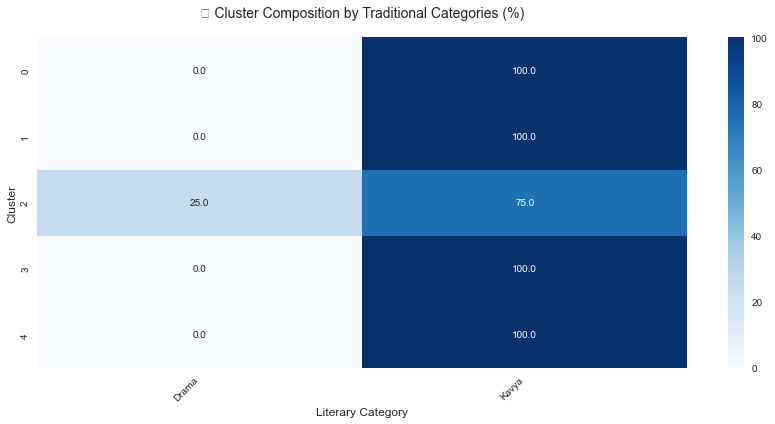

In [84]:
# Cluster composition analysis
if results_df is not None:
    print("📊 Cluster Composition Analysis")
    print("=" * 50)
    
    # Cluster summary
    cluster_summary = results_df.groupby('Cluster').agg({
        'Work': 'count',
        'Group': lambda x: x.value_counts().to_dict()
    }).rename(columns={'Work': 'Text_Count'})
    
    # Create composition heatmap
    composition_matrix = pd.crosstab(results_df['Cluster'], results_df['Group'], normalize='index') * 100
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(composition_matrix, annot=True, fmt='.1f', cmap='Blues', ax=ax)
    ax.set_title('📊 Cluster Composition by Traditional Categories (%)', fontsize=14, pad=20)
    ax.set_xlabel('Literary Category', fontsize=12)
    ax.set_ylabel('Cluster', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # # List cluster details
    # for cluster in sorted(results_df['Cluster'].unique()):
    #     cluster_data = results_df[results_df['Cluster'] == cluster]
    #     print(f"\n🏷️ Cluster {cluster} ({len(cluster_data)} texts):")
        
    #     # Category distribution
    #     cat_dist = cluster_data['Group'].value_counts()
    #     for cat, count in cat_dist.items():
    #         percentage = (count / len(cluster_data)) * 100
    #         print(f"  • {cat}: {count} texts ({percentage:.1f}%)")
        
    #     all_texts = cluster_data['Work'].tolist()
    #     all_groups = cluster_data['Group'].tolist()
    #     display( pd.DataFrame({
    #         'Text': all_texts,
    #         'Group': all_groups
    #     }))

        # # Sample texts
        # sample_texts = cluster_data['Work'].head(5).tolist()
        # if len(cluster_data) > 5:
        #     print(f"  📚 Sample texts: {', '.join(sample_texts)}... and {len(cluster_data)-5} more")
        # else:
        #     print(f"  📚 Texts: {', '.join(sample_texts)}")

## Section 7: Phonetic Signature Analysis

Discover the characteristic sounds that define each cluster.

🎵 Phonetic Signature Analysis


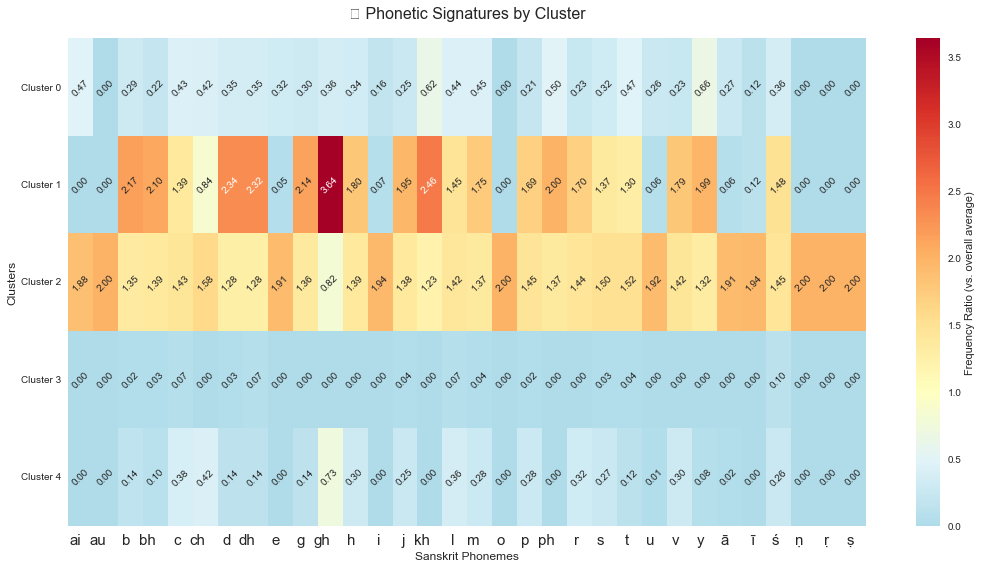


💡 Interpretation Guide:
  • Values > 1.0: Phoneme is more frequent in this cluster
  • Values < 1.0: Phoneme is less frequent in this cluster
  • Red colors: Higher frequency, Blue colors: Lower frequency


In [87]:
# Phonetic signature analysis
if results_df is not None and X_scaled is not None:
    print("🎵 Phonetic Signature Analysis")
    print("=" * 45)
    
    # Calculate cluster centers and characteristics
    selected_works = results_df['Work'].tolist()
    X_original = gsc_filtered[selected_works].T  # Original frequencies
    phonemes = gsc_filtered.index.tolist()
    
    cluster_signatures = {}
    
    for cluster in sorted(results_df['Cluster'].unique()):
        if cluster == -1:  # Skip outliers for now
            continue
            
        cluster_texts = results_df[results_df['Cluster'] == cluster]['Work']
        cluster_indices = [selected_works.index(text) for text in cluster_texts]
        
        # Calculate mean frequencies for this cluster
        cluster_mean = X_original.iloc[cluster_indices].mean()
        overall_mean = X_original.mean()
        
        # Find distinctive phonemes (higher than average)
        phoneme_ratios = cluster_mean / (overall_mean + 1e-10)  # Avoid division by zero
        distinctive_phonemes = phoneme_ratios.sort_values(ascending=False).head(10)
        
        cluster_signatures[cluster] = {
            'mean_frequencies': cluster_mean,
            'distinctive_sounds': distinctive_phonemes,
            'text_count': len(cluster_texts)
        }
        
        # print(f"\n🏷️ Cluster {cluster} Signature ({len(cluster_texts)} texts):")
        # print(f"  🎶 Most distinctive sounds:")
        # for phoneme, ratio in distinctive_phonemes.head(5).items():
        #     print(f"    • {phoneme}: {ratio:.2f}x more frequent than average")
    
    # Create phonetic signature heatmap
    signature_data = []
    cluster_names = []
    
    for cluster in sorted(cluster_signatures.keys()):
        signature_data.append(cluster_signatures[cluster]['distinctive_sounds'].head(15).values)
        cluster_names.append(f'Cluster {cluster}')
    
    # Get top phonemes across all clusters
    all_top_phonemes = set()
    for cluster in cluster_signatures.keys():
        all_top_phonemes.update(cluster_signatures[cluster]['distinctive_sounds'].head(15).index)
    
    top_phonemes = sorted(list(all_top_phonemes))
    
    # Create signature matrix
    signature_matrix = pd.DataFrame(index=cluster_names, columns=top_phonemes)
    
    for cluster in cluster_signatures.keys():
        cluster_name = f'Cluster {cluster}'
        for phoneme in top_phonemes:
            if phoneme in cluster_signatures[cluster]['distinctive_sounds']:
                signature_matrix.loc[cluster_name, phoneme] = cluster_signatures[cluster]['distinctive_sounds'][phoneme]
            else:
                overall_mean = X_original.mean()
                cluster_texts = results_df[results_df['Cluster'] == cluster]['Work']
                cluster_indices = [selected_works.index(text) for text in cluster_texts]
                cluster_mean = X_original.iloc[cluster_indices].mean()
                signature_matrix.loc[cluster_name, phoneme] = cluster_mean[phoneme] / (overall_mean[phoneme] + 1e-10)
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(15, 8))
    sns.heatmap(signature_matrix.astype(float), 
                annot=True, fmt='.2f', cmap='RdYlBu_r', 
                center=1.0, ax=ax,
                cbar_kws={'label': 'Frequency Ratio (vs. overall average)'},
                annot_kws={"size": 10, "rotation": 45}
                )
    ax.set_title('🎵 Phonetic Signatures by Cluster', fontsize=16, pad=20)
    ax.set_xlabel('Sanskrit Phonemes', fontsize=12)
    ax.set_ylabel('Clusters', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=15 )
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretation Guide:")
    print("  • Values > 1.0: Phoneme is more frequent in this cluster")
    print("  • Values < 1.0: Phoneme is less frequent in this cluster")
    print("  • Red colors: Higher frequency, Blue colors: Lower frequency")

## Section 8: Hierarchical Analysis

Explore the hierarchical relationships between texts, especially useful for understanding literary genealogies.

In [ ]:
# Hierarchical clustering analysis
if results_df is not None and X_scaled is not None:
    print("🌳 Hierarchical Text Relationships")
    print("=" * 45)
    
    # Create linkage matrix for dendrogram
    linkage_matrix = linkage(X_scaled, method='ward')
    
    # Create dendrogram
    fig, ax = plt.subplots(figsize=(15, 13))
    
    # Create dendrogram with text labels
    selected_works = results_df['Work'].tolist()
    
    # Truncate text names if too long
    display_names = [name[3:20] + '...' if len(name) > 20 else name for name in selected_works]
    
    dendrogram_result = dendrogram(
        linkage_matrix,
        labels=display_names,
        ax=ax,
        orientation='bottom',
        leaf_rotation=90,
        leaf_font_size=12
    )
    
    ax.set_title('🌳 Sanskrit Text Dendrogram - Phonetic Relationships', fontsize=16, pad=20)
    ax.set_xlabel('Sanskrit Texts', fontsize=12)
    ax.set_ylabel('Phonetic Distance', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Similarity matrix
    print("\n🔗 Creating Text Similarity Network...")
    
    # Calculate pairwise similarities
    similarity_matrix = cosine_similarity(X_scaled)
    similarity_df = pd.DataFrame(
        similarity_matrix, 
        index=selected_works, 
        columns=selected_works
    )
    
    # Find most similar text pairs
    print("\n🎯 Most Similar Text Pairs (excluding self-similarity):")
    
    # Get upper triangle of similarity matrix (excluding diagonal)
    similarity_pairs = []
    for i in range(len(selected_works)):
        for j in range(i+1, len(selected_works)):
            similarity_pairs.append({
                'Text1': selected_works[i],
                'Text2': selected_works[j],
                'Similarity': similarity_matrix[i, j],
                'Category1': results_df[results_df['Work'] == selected_works[i]]['Group'].iloc[0],
                'Category2': results_df[results_df['Work'] == selected_works[j]]['Group'].iloc[0]
            })
    
    similarity_pairs_df = pd.DataFrame(similarity_pairs)
    top_similarities = similarity_pairs_df.sort_values('Similarity', ascending=False).head(10)
    
    for _, row in top_similarities.iterrows():
        cross_category = "📚" if row['Category1'] != row['Category2'] else "📖"
        print(f"  {cross_category} {row['Text1'][3:]} ↔ {row['Text2'][3:]} (similarity: {row['Similarity']:.3f})")
        if row['Category1'] != row['Category2']:
            print(f"      └─ Cross-category: {row['Category1'][3:]} ↔ {row['Category2'][3:]}")
    
    print("\n💡 📚 = Cross-category similarity (potentially interesting!)")
    print("💡 📖 = Same-category similarity (expected)")

## Section 9: Literary Insights and Discussion Points

Interpret the clustering results in the context of Sanskrit literary traditions.

In [ ]:
# Literary insights generation
if results_df is not None:
    print("📖 Literary Insights and Discussion Points")
    print("=" * 50)
    
    # Analyze cross-category clusters
    print("\n🔍 Cross-Category Clustering Analysis:")
    
    for cluster in sorted(results_df['Cluster'].unique()):
        if cluster == -1:
            continue
            
        cluster_data = results_df[results_df['Cluster'] == cluster]
        categories = cluster_data['Group'].unique()
        
        if len(categories) > 1:
            print(f"\n🎭 Cluster {cluster} - Cross-Traditional Grouping:")
            print(f"  📚 Categories: {', '.join(categories)}")
            print(f"  📖 Texts: {', '.join(cluster_data['Work'].tolist())}")
            
            # Look up distinctive sounds for interpretation
            if cluster in cluster_signatures:
                top_sounds = cluster_signatures[cluster]['distinctive_sounds'].head(3)
                print(f"  🎵 Distinctive sounds: {', '.join(top_sounds.index)}")
            
            print(f"  💭 Discussion: What phonetic characteristics unite these diverse texts?")
    
    # Analyze pure clusters
    print("\n🏛️ Traditional Category Alignments:")
    
    for cluster in sorted(results_df['Cluster'].unique()):
        if cluster == -1:
            continue
            
        cluster_data = results_df[results_df['Cluster'] == cluster]
        dominant_category = cluster_data['Group'].mode().iloc[0]
        category_purity = (cluster_data['Group'] == dominant_category).mean()
        
        if category_purity >= 0.8:  # 80% or more from same category
            print(f"\n📚 Cluster {cluster} - {dominant_category} Core ({category_purity:.0%} purity):")
            print(f"  📖 Representative texts: {', '.join(cluster_data['Work'].head(3))}")
            
            if cluster in cluster_signatures:
                top_sounds = cluster_signatures[cluster]['distinctive_sounds'].head(3)
                print(f"  🎵 Signature sounds: {', '.join(top_sounds.index)}")
    
    # Outlier analysis
    outliers = results_df[results_df['Cluster'] == -1]
    if len(outliers) > 0:
        print(f"\n🔍 Phonetic Outliers ({len(outliers)} texts):")
        for _, outlier in outliers.iterrows():
            print(f"  • {outlier['Work']} ({outlier['Group']})")
        print("  💭 Discussion: What makes these texts phonetically unique?")
    
    # Generate discussion questions
    print("\n💭 Questions for Scholarly Discussion:")
    print("=" * 40)
    
    questions = [
        "How do the phonetic clusters align with or challenge traditional literary categories?",
        "What historical or regional factors might explain cross-category phonetic similarities?",
        "Do certain phonetic signatures correlate with specific poetic meters or styles?",
        "How might authorship, time period, or regional origin influence phonetic patterns?",
        "What can phonetic outliers tell us about unique literary traditions or innovations?",
        "How do these patterns reflect the evolution of Sanskrit literary language?"
    ]
    
    for i, question in enumerate(questions, 1):
        print(f"  {i}. {question}")
    
    print("\n📊 Quantitative Summary:")
    print(f"  • Total texts analyzed: {len(results_df)}")
    print(f"  • Clusters found: {len(results_df['Cluster'].unique()) - (1 if -1 in results_df['Cluster'].unique() else 0)}")
    print(f"  • Literary categories: {results_df['Group'].nunique()}")
    print(f"  • Cross-category clusters: {sum(1 for cluster in results_df['Cluster'].unique() if cluster != -1 and len(results_df[results_df['Cluster'] == cluster]['Group'].unique()) > 1)}")
    
    if 'sil_score' in locals():
        print(f"  • Clustering quality (silhouette): {sil_score:.3f}")
    
    print(f"  • Sanskrit phonemes analyzed: {len(gsc_filtered)}")

## Section 10: Export and Save Results

Save your analysis results for further discussion and academic use.

In [ ]:
# Export results
def export_results():
    if results_df is None:
        print("❌ No results to export")
        return
    
    print("💾 Exporting Analysis Results...")
    
    # Export cluster assignments
    results_df.to_csv('sanskrit_clustering_results.csv', index=False)
    print("✅ Cluster assignments saved to: sanskrit_clustering_results.csv")
    
    # Export similarity matrix
    if 'similarity_df' in locals():
        similarity_df.to_csv('sanskrit_text_similarities.csv')
        print("✅ Text similarities saved to: sanskrit_text_similarities.csv")
    
    # Export cluster signatures
    if 'cluster_signatures' in locals():
        signature_export = []
        for cluster, data in cluster_signatures.items():
            for phoneme, ratio in data['distinctive_sounds'].items():
                signature_export.append({
                    'Cluster': cluster,
                    'Phoneme': phoneme,
                    'Frequency_Ratio': ratio
                })
        
        signature_df = pd.DataFrame(signature_export)
        signature_df.to_csv('sanskrit_phonetic_signatures.csv', index=False)
        print("✅ Phonetic signatures saved to: sanskrit_phonetic_signatures.csv")
    
    # Create summary report
    summary_text = f"""Sanskrit Text Clustering Analysis Summary
=============================================

Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
Algorithm Used: {algorithm_selector.value}
Number of Clusters: {n_clusters_slider.value}
Normalization: {normalization_selector.value}

Dataset Overview:
- Total texts analyzed: {len(results_df)}
- Literary categories: {results_df['Group'].nunique()}
- Sanskrit phonemes: {len(gsc_filtered)}

Clustering Results:
- Clusters found: {len(results_df['Cluster'].unique()) - (1 if -1 in results_df['Cluster'].unique() else 0)}
- Cross-category clusters: {sum(1 for cluster in results_df['Cluster'].unique() if cluster != -1 and len(results_df[results_df['Cluster'] == cluster]['Group'].unique()) > 1)}
"""
    
    if 'sil_score' in locals():
        summary_text += f"- Silhouette score: {sil_score:.3f}\n"
    
    summary_text += "\n\nCluster Compositions:\n"
    for cluster in sorted(results_df['Cluster'].unique()):
        if cluster == -1:
            continue
        cluster_data = results_df[results_df['Cluster'] == cluster]
        summary_text += f"\nCluster {cluster} ({len(cluster_data)} texts):\n"
        cat_dist = cluster_data['Group'].value_counts()
        for cat, count in cat_dist.items():
            percentage = (count / len(cluster_data)) * 100
            summary_text += f"  - {cat}: {count} texts ({percentage:.1f}%)\n"
    
    with open('sanskrit_clustering_summary.txt', 'w', encoding='utf-8') as f:
        f.write(summary_text)
    
    print("✅ Summary report saved to: sanskrit_clustering_summary.txt")
    print("\n📧 Ready for sharing with colleagues and collaborators!")

# Add export button
export_button = widgets.Button(
    description='💾 Export Results',
    button_style='success',
    tooltip='Save all analysis results to CSV and text files'
)

export_button.on_click(lambda x: export_results())

print("📁 Export Analysis Results")
print("Save your clustering analysis for academic discussion and further research:")
display(export_button)

## Conclusion and Next Steps

🎭 **Congratulations!** You've completed a comprehensive phonetic clustering analysis of Sanskrit texts.

### What You've Discovered:
- **Phonetic relationships** between Sanskrit texts that transcend traditional categories
- **Characteristic sound signatures** that define different textual clusters
- **Cross-traditional patterns** that reveal hidden literary connections
- **Quantitative insights** into the sonic landscape of Sanskrit literature

### For Further Exploration:
1. **Experiment with different algorithms** and parameter settings
2. **Focus on specific literary periods** or regional traditions
3. **Compare results with metrical analysis** and other literary features
4. **Investigate outliers** for unique phonetic characteristics
5. **Share findings** with fellow Sanskrit scholars and poets

### Academic Applications:
- **Literary genealogy** studies using phonetic evidence
- **Authorship attribution** research
- **Historical linguistics** investigations
- **Poetic tradition** evolution analysis
- **Cross-cultural** Sanskrit literature comparisons

---

*This notebook was designed to bridge computational analysis with traditional Sanskrit scholarship. May it inspire new insights into the eternal beauty of Sanskrit literature!*

🙏 **सर्वे भवन्तु सुखिनः सर्वे सन्तु निरामयाः**